# Agrupamento e Análise (Data de conclusão: 9 de março de 2026 às 16:00)

## Instruções

**Análise de Recuperação de Veículos**

Utilize a mesma base de dados `03.BaseDPEvolucaoMensalCisp.csv` usada anteriormente na análise de roubo de veículos. Nesta atividade, você irá investigar quantos veículos foram recuperados e identificar qual ano teve a maior quantidade de recuperações.

### 1. Quantidade de veículos recuperados por município

Crie um novo script em Python ou adapte o código já utilizado na análise de roubo de veículos.

### Passos

1. Importe as bibliotecas necessárias.
2. Carregue o arquivo CSV usando pandas.
3. Selecione apenas as colunas: `munic`, `recuperacao_veiculos`.
4. Agrupe os dados por município.
5. Some o total de veículos recuperados.
6. Ordene os resultados do maior para o menor.
7. Exiba os 10 municípios com maior número de veículos recuperados.

### Perguntas para responder

- Existe grande diferença entre os primeiros municípios do ranking?
- Compare com o ranking de roubo de veículos. O município que mais tem roubos também lidera em recuperações?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Carregar o arquivo CSV com tratamento de erro
try:
    df = pd.read_csv('03.BaseDPEvolucaoMensalCisp.csv', encoding='iso-8859-1', sep=';')
    print(df.columns)
except Exception as e:
    print(f'Erro: {e}')


Index(['cisp', 'mes', 'ano', 'mes_ano', 'aisp', 'risp', 'munic', 'mcirc',
       'regiao', 'hom_doloso', 'lesao_corp_morte', 'latrocinio', 'cvli',
       'hom_por_interv_policial', 'letalidade_violenta', 'tentat_hom',
       'lesao_corp_dolosa', 'estupro', 'hom_culposo', 'lesao_corp_culposa',
       'roubo_transeunte', 'roubo_celular', 'roubo_em_coletivo', 'roubo_rua',
       'roubo_veiculo', 'roubo_carga', 'roubo_comercio', 'roubo_residencia',
       'roubo_banco', 'roubo_cx_eletronico', 'roubo_conducao_saque',
       'roubo_apos_saque', 'roubo_bicicleta', 'outros_roubos', 'total_roubos',
       'furto_veiculos', 'furto_transeunte', 'furto_coletivo', 'furto_celular',
       'furto_bicicleta', 'outros_furtos', 'total_furtos', 'sequestro',
       'extorsao', 'sequestro_relampago', 'estelionato', 'apreensao_drogas',
       'posse_drogas', 'trafico_drogas', 'apreensao_drogas_sem_autor',
       'recuperacao_veiculos', 'apf', 'aaapai', 'cmp', 'cmba', 'ameaca',
       'pessoas_desaparecidas'

In [3]:
# Selecionar colunas de interesse
# munic, recuperacao_veiculos

# Agrupar por município e somar as recuperações
df_recuperacao = df[['munic', 'recuperacao_veiculos']]
df_recuperacao = df_recuperacao.groupby('munic').sum().reset_index()

# Ordenar do maior para o menor
df_recuperacao = df_recuperacao.sort_values(by='recuperacao_veiculos', ascending=False)

# Exibir os 10 municípios com maior número de veículos recuperados
df_recuperacao.head(10)
# numa análise futura, se for fazer um gráfico a função head poderia travar
# neste caso a função head é apenas para visualização rápida
# para gráficos, é melhor usar todo o DataFrame ou uma amostra maior
# sugere-se o uso do iloc [:10] para selecionar as 10 primeiras linhas
df_recuperacao.iloc[:10]

,munic,recuperacao_veiculos
68,Rio de Janeiro,269057
23,Duque de Caxias,42959
78,São Gonçalo,39574
81,São João de Meriti,19341
50,Nova Iguaçu,17217
48,Niterói,15417
6,Belford Roxo,14164
13,Campos dos Goytacazes,5334
47,Nilópolis,5257
43,Mesquita,5000


In [4]:
# Medidas de tendência central
recuperacao_array = np.array(df_recuperacao['recuperacao_veiculos'])

media_recuperacao = np.mean(recuperacao_array)
mediana_recuperacao = np.median(recuperacao_array)
moda_recuperacao = pd.Series(recuperacao_array).mode()

print(f"Média: {media_recuperacao}")
print(f"Mediana: {mediana_recuperacao}")
print("Moda:")
print(moda_recuperacao)

# Medidas de dispersão
amplitude = np.max(recuperacao_array) - np.min(recuperacao_array)
variancia = np.var(recuperacao_array)
desvio_padrao = np.std(recuperacao_array)
cv = desvio_padrao / media_recuperacao if media_recuperacao != 0 else np.nan

print(f"Amplitude: {amplitude}")
print(f"Variância: {variancia}")
print(f"Desvio padrão: {desvio_padrao}")
print(f"Coeficiente de variação: {cv}")

# Medidas de posição
q1 = np.quantile(recuperacao_array, 0.25)
q2 = np.quantile(recuperacao_array, 0.50)
q3 = np.quantile(recuperacao_array, 0.75)
iqr = q3 - q1

print(f"Q1: {q1}")
print(f"Q2 (mediana): {q2}")
print(f"Q3: {q3}")
print(f"IQR: {iqr}")


Média: 5460.988888888889
Mediana: 370.5
Moda:
0      24
1      72
2    1151
dtype: int64
Amplitude: 269033
Variância: 826819914.9443208
Desvio padrão: 28754.476433145515
Coeficiente de variação: 5.265433975090177
Q1: 144.5
Q2 (mediana): 370.5
Q3: 1626.5
IQR: 1482.0


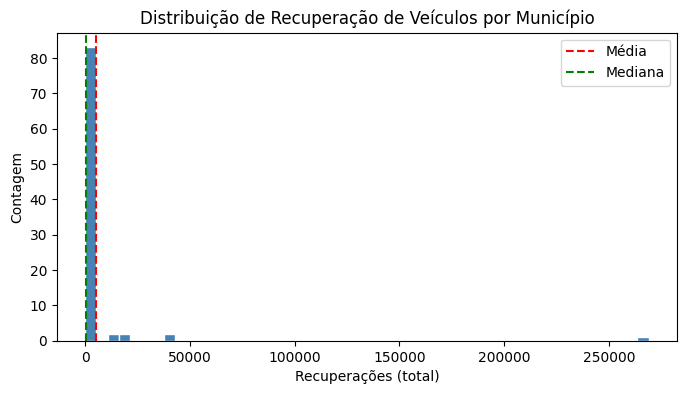

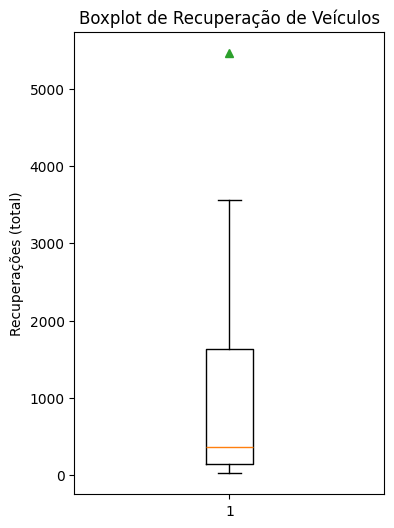

In [5]:
# Gráficos de distribuição
plt.figure(figsize=(8, 4))
plt.hist(recuperacao_array, bins=50, color='steelblue', edgecolor='white')
plt.axvline(x=media_recuperacao, color='red', linestyle='--', label='Média')
plt.axvline(x=mediana_recuperacao, color='green', linestyle='--', label='Mediana')
plt.title('Distribuição de Recuperação de Veículos por Município')
plt.xlabel('Recuperações (total)')
plt.ylabel('Contagem')
plt.legend()
plt.show()

plt.figure(figsize=(4, 6))
plt.boxplot(recuperacao_array, vert=True, showmeans=True, showfliers=False)
plt.title('Boxplot de Recuperação de Veículos')
plt.ylabel('Recuperações (total)')
plt.show()


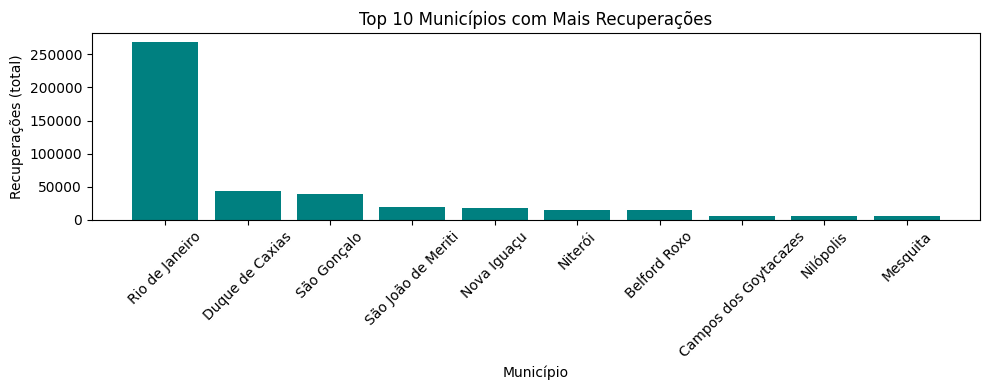

In [6]:
# Top 10 municípios com mais recuperações
plt.figure(figsize=(10, 4))
plt.bar(df_recuperacao.iloc[:10]['munic'], df_recuperacao.iloc[:10]['recuperacao_veiculos'], color='teal')
plt.xticks(rotation=45)
plt.title('Top 10 Municípios com Mais Recuperações')
plt.ylabel('Recuperações (total)')
plt.xlabel('Município')
plt.tight_layout()
plt.show()


Ano com mais recuperações: 2017 (37630)


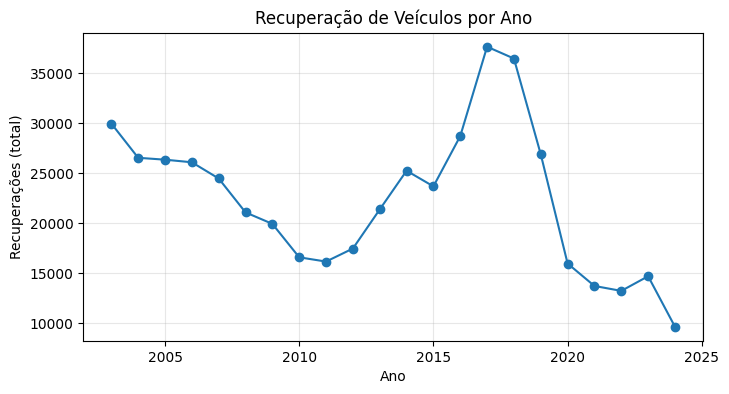

In [7]:
# Recuperações por ano
recuperacao_por_ano = df.groupby('ano')['recuperacao_veiculos'].sum().reset_index()
recuperacao_por_ano = recuperacao_por_ano.sort_values(by='recuperacao_veiculos', ascending=False)

# Ano com maior número de recuperações
ano_top = recuperacao_por_ano.iloc[0]
print(f"Ano com mais recuperações: {int(ano_top['ano'])} ({int(ano_top['recuperacao_veiculos'])})")

# Visualização por ano (ordenado cronologicamente)
recuperacao_por_ano_ordenado = recuperacao_por_ano.sort_values(by='ano')
plt.figure(figsize=(8, 4))
plt.plot(recuperacao_por_ano_ordenado['ano'], recuperacao_por_ano_ordenado['recuperacao_veiculos'], marker='o')
plt.title('Recuperação de Veículos por Ano')
plt.xlabel('Ano')
plt.ylabel('Recuperações (total)')
plt.grid(True, alpha=0.3)
plt.show()


In [8]:
# Ranking de roubo de veículos para comparação
# munic, roubo_veiculo

df_roubo = df[['munic', 'roubo_veiculo']].groupby('munic').sum().reset_index()
df_roubo = df_roubo.sort_values(by='roubo_veiculo', ascending=False)

# Comparar líderes
# iloc é usado para acessar a primeira linha do DataFrame
lider_roubo = df_roubo.iloc[0]
lider_recuperacao = df_recuperacao.iloc[0]

print(f"Líder em roubo: {lider_roubo['munic']} ({lider_roubo['roubo_veiculo']})")
print(f"Líder em recuperação: {lider_recuperacao['munic']} ({lider_recuperacao['recuperacao_veiculos']})")


Líder em roubo: Rio de Janeiro (372584)
Líder em recuperação: Rio de Janeiro (269057)


In [9]:
# Vamos calcular a curtose e assimetria para verificar melhor como os roubos e recuperaçõe spodem explicar melhort o que aconteceu


Análise dos resultados
Os totais de recuperação estão concentrados em poucos municípios, com forte assimetria. A média ficou bem acima da mediana, indicando distribuição puxada por valores extremos. O boxplot confirma a presença de outliers, o que reforça que poucos municípios concentram grande parte das recuperações.
No recorte temporal, o pico ocorreu em 2017, seguido de queda nos anos posteriores. Isso sugere mudanças de contexto operacional ou de registro ao longo do tempo.
Na comparação com o ranking de roubos, o município líder em roubos também lidera em recuperações, indicando maior volume de ocorrências e possivelmente maior esforço policial na mesma região.